# G6V1 - Integración de datos desde CSV, Excel, JSON y SQL relacional

**Versión aprendiz.**

En este notebook se integran cuatro fuentes estructuradas para construir un dataset único por cliente.

## 1. Propósito

Construir un dataset integrado usando `ID_Cliente` como llave común. La integración combina datos maestros, transacciones de compras, interacciones web y satisfacción del cliente.

In [1]:
from pathlib import Path
import sqlite3
import pandas as pd
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus
import matplotlib.pyplot as plt
import urllib.request

DATA_DIR = Path("../03_data")
OUT_DIR = Path("../08_revision/evidencias")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR.resolve())
print("OUT_DIR:", OUT_DIR.resolve())

DATA_DIR: C:\Users\SENA\Documents\VS_CODE\Sena_IA_1\IA_1\6-Integracion_Datos_Multiples_Fuentes-20260624T120509Z-3-001\6-Integracion_Datos_Multiples_Fuentes\03_data
OUT_DIR: C:\Users\SENA\Documents\VS_CODE\Sena_IA_1\IA_1\6-Integracion_Datos_Multiples_Fuentes-20260624T120509Z-3-001\6-Integracion_Datos_Multiples_Fuentes\08_revision\evidencias


## 2. Carga de fuentes

Se cargan archivos en cuatro formatos: CSV, Excel, JSON y SQL relacional.

In [15]:
# 1. Datos de conexión

servidor = r".\SQLEXPRESS"   # Cambia esto según tu servidor
base_datos = "empresa_integracion.db"
driver = "ODBC Driver 18 for SQL Server"

# 2. Cadena de conexión con Autenticación de Windows

cadena_conexion = quote_plus(
    f"DRIVER={driver};"
    f"SERVER={servidor};"
    f"DATABASE={base_datos};"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

# 3. Crear motor de conexión

engine = create_engine(
    f"mssql+pyodbc:///?odbc_connect={cadena_conexion}"
)

# 4. Probar conexión

try:
    with engine.connect() as conexion:
        resultado = conexion.execute(text("SELECT DB_NAME() AS BaseActual;"))
        for fila in resultado:
            print("Conexión exitosa a la base de datos:", fila.BaseActual)

except Exception as e:
    print("Error de conexión:")
    print(e)

Conexión exitosa a la base de datos: empresa_integracion.db


In [12]:
Consulta = """ 
SELECT Satisfaccion, QuejasUltimos6M
FROM satisfaccion_clientes;
"""
df = pd.read_sql(Consulta, engine)
df.head()

,Satisfaccion,QuejasUltimos6M
0,Media,2
1,Baja,1
2,Alta,4
3,Media,1
4,Media,1


In [14]:
Consulta = """ 
SELECT *
FROM satisfaccion_clientes;
"""
df = pd.read_sql(Consulta, engine)
df.head()

,ID_Cliente,Satisfaccion,QuejasUltimos6M
0,C0001,Media,2
1,C0002,Baja,1
2,C0003,Alta,4
3,C0004,Media,1
4,C0005,Media,1


In [16]:
clientes = pd.read_csv("https://raw.githubusercontent.com/yoximarcamachoc-alt/python-sena-/refs/heads/main/clientes.csv")

try:
    compras = pd.read_excel("https://github.com/yoximarcamachoc-alt/python-sena-/blob/main/compras.xlsx?raw=true", sheet_name="compras")
except Exception as e:
    print("No se pudo leer compras.xlsx. Se usará compras_respaldo.csv. Detalle:", e)
    compras = pd.read_csv("https://raw.githubusercontent.com/yoximarcamachoc-alt/python-sena-/refs/heads/main/compras_respaldo.csv")

web = pd.read_json("https://raw.githubusercontent.com/yoximarcamachoc-alt/python-sena-/refs/heads/main/interacciones_web.json")


DB_NAME = "empresa_integracion.db"

DB_URL = (
    "https://raw.githubusercontent.com/"
    "yoximarcamachoc-alt/python-sena-/main/empresa_integracion.db"
)

db_path = Path(DB_NAME)

if not db_path.exists():
    print(" Descargando empresa_integracion.db...")
    urllib.request.urlretrieve(DB_URL, db_path)
    print(" Base descargada correctamente.")
else:
    print(" Base de datos encontrada localmente.")

conn = sqlite3.connect(db_path)

satisfaccion = pd.read_sql_query(
    "SELECT * FROM satisfaccion_clientes",
    conn
)

conn.close()

print("clientes:", clientes.shape)
print("compras:", compras.shape)
print("web:", web.shape)
print("satisfaccion:", satisfaccion.shape)

 Descargando empresa_integracion.db...
 Base descargada correctamente.
clientes: (160, 6)
compras: (590, 6)
web: (160, 4)
satisfaccion: (160, 3)


## 3. Diagnóstico inicial

Antes de unir, se revisa la calidad de cada fuente.

In [14]:
fuentes = {
    "clientes": clientes,
    "compras": compras,
    "web": web,
    "satisfaccion": satisfaccion
}

for nombre, df in fuentes.items():
    print("\nFuente:", nombre)
    print("Dimensiones:", df.shape)
    print("Duplicados:", df.duplicated().sum())
    print("Nulos por columna:")
    print(df.isna().sum())


Fuente: clientes
Dimensiones: (160, 6)
Duplicados: 0
Nulos por columna:
ID_Cliente        0
Edad              0
Ciudad            0
Segmento          0
FechaRegistro     0
CanalPreferido    0
dtype: int64

Fuente: compras
Dimensiones: (590, 6)
Duplicados: 3
Nulos por columna:
ID_Cliente           0
FechaCompra          0
CategoriaProducto    0
Cantidad             0
ValorUnitario        0
Descuento            0
dtype: int64

Fuente: web
Dimensiones: (160, 4)
Duplicados: 0
Nulos por columna:
ID_Cliente                 0
VisitasWebUltimoMes        0
TiempoPromedioSesionMin    0
FuenteWeb                  0
dtype: int64

Fuente: satisfaccion
Dimensiones: (160, 3)
Duplicados: 0
Nulos por columna:
ID_Cliente         0
Satisfaccion       0
QuejasUltimos6M    0
dtype: int64


## 4. Normalización de llaves y fechas

La llave `ID_Cliente` debe quedar limpia y comparable en todas las fuentes.

In [15]:
for df in [clientes, compras, web, satisfaccion]:
    df["ID_Cliente"] = df["ID_Cliente"].astype(str).str.strip().str.upper()

clientes["FechaRegistro"] = pd.to_datetime(clientes["FechaRegistro"], errors="coerce")
compras["FechaCompra"] = pd.to_datetime(compras["FechaCompra"], errors="coerce")

clientes.head()

,ID_Cliente,Edad,Ciudad,Segmento,FechaRegistro,CanalPreferido
0,C0001,56,Cali,Medio,2024-08-02,App
1,C0002,46,Cartagena,Básico,2024-08-22,App
2,C0003,32,Cartagena,Básico,2025-08-10,App
3,C0004,60,Barranquilla,Medio,2024-01-09,Web
4,C0005,25,Cartagena,Medio,2024-03-14,Web


## 5. Validación de correspondencia

Se identifican transacciones que no tienen cliente asociado. Esto es importante para la trazabilidad.

In [16]:
ids_clientes = set(clientes["ID_Cliente"])
compras_sin_cliente = compras[~compras["ID_Cliente"].isin(ids_clientes)]

print("Compras con ID_Cliente inexistente en clientes:", len(compras_sin_cliente))
compras_sin_cliente.head()

Compras con ID_Cliente inexistente en clientes: 2


,ID_Cliente,FechaCompra,CategoriaProducto,Cantidad,ValorUnitario,Descuento
585,C9999,2025-08-10,Tecnología,1,150000,0.05
586,C8888,2025-09-12,Servicios,2,60000,0.00


## 6. Agregación de compras por cliente

Como compras tiene varias filas por cliente, primero se agregan las transacciones para evitar duplicar clientes en el dataset final.

In [17]:
compras["ValorNeto"] = compras["Cantidad"] * compras["ValorUnitario"] * (1 - compras["Descuento"])
compras_validas = compras[compras["ID_Cliente"].isin(ids_clientes)].copy()

compras_agregadas = (
    compras_validas
    .groupby("ID_Cliente")
    .agg(
        TotalCompras=("ID_Cliente", "count"),
        ValorTotalCompras=("ValorNeto", "sum"),
        TicketPromedio=("ValorNeto", "mean"),
        UltimaCompra=("FechaCompra", "max")
    )
    .reset_index()
)

compras_agregadas["ValorTotalCompras"] = compras_agregadas["ValorTotalCompras"].round(2)
compras_agregadas["TicketPromedio"] = compras_agregadas["TicketPromedio"].round(2)

compras_agregadas.head()

,ID_Cliente,TotalCompras,ValorTotalCompras,TicketPromedio,UltimaCompra
0,C0001,1,587030.4,587030.40,2025-10-23
1,C0002,1,74219.7,74219.70,2025-08-01
2,C0003,2,307306.9,153653.45,2025-10-23
3,C0004,4,726085.8,181521.45,2025-12-19
4,C0005,5,1674417.2,334883.44,2025-11-20


## 7. Integración de fuentes

Se usa `merge` tipo `left` para conservar todos los clientes del maestro.

In [18]:
dataset = clientes.merge(compras_agregadas, on="ID_Cliente", how="left")
dataset = dataset.merge(web, on="ID_Cliente", how="left")
dataset = dataset.merge(satisfaccion, on="ID_Cliente", how="left")

dataset["TotalCompras"] = dataset["TotalCompras"].fillna(0).astype(int)
dataset["ValorTotalCompras"] = dataset["ValorTotalCompras"].fillna(0)
dataset["TicketPromedio"] = dataset["TicketPromedio"].fillna(0)

print("Dataset integrado:", dataset.shape)
dataset.head()

Dataset integrado: (160, 15)


,ID_Cliente,Edad,Ciudad,Segmento,FechaRegistro,CanalPreferido,TotalCompras,ValorTotalCompras,TicketPromedio,UltimaCompra,VisitasWebUltimoMes,TiempoPromedioSesionMin,FuenteWeb,Satisfaccion,QuejasUltimos6M
0,C0001,56,Cali,Medio,2024-08-02,App,1,587030.4,587030.40,2025-10-23,3,2.81,Anuncio pagado,Media,2
1,C0002,46,Cartagena,Básico,2024-08-22,App,1,74219.7,74219.70,2025-08-01,4,0.80,Redes sociales,Baja,1
2,C0003,32,Cartagena,Básico,2025-08-10,App,2,307306.9,153653.45,2025-10-23,4,5.64,Referido,Alta,4
3,C0004,60,Barranquilla,Medio,2024-01-09,Web,4,726085.8,181521.45,2025-12-19,6,1.96,Orgánico,Media,1
4,C0005,25,Cartagena,Medio,2024-03-14,Web,5,1674417.2,334883.44,2025-11-20,9,4.16,Email,Media,1


## 8. Validación del dataset integrado

In [19]:
print("Duplicados por ID_Cliente:", dataset["ID_Cliente"].duplicated().sum())
print("\nNulos finales:")
print(dataset.isna().sum())
print("\nFilas y columnas:", dataset.shape)

Duplicados por ID_Cliente: 0

Nulos finales:
ID_Cliente                  0
Edad                        0
Ciudad                      0
Segmento                    0
FechaRegistro               0
CanalPreferido              0
TotalCompras                0
ValorTotalCompras           0
TicketPromedio              0
UltimaCompra               10
VisitasWebUltimoMes         0
TiempoPromedioSesionMin     0
FuenteWeb                   0
Satisfaccion                0
QuejasUltimos6M             0
dtype: int64

Filas y columnas: (160, 15)


## 9. Indicadores básicos

In [20]:
indicadores_segmento = (
    dataset.groupby("Segmento")
    .agg(
        Clientes=("ID_Cliente", "count"),
        ValorTotal=("ValorTotalCompras", "sum"),
        TicketPromedio=("TicketPromedio", "mean"),
        QuejasPromedio=("QuejasUltimos6M", "mean")
    )
    .round(2)
    .reset_index()
)

indicadores_ciudad = (
    dataset.groupby("Ciudad")
    .agg(
        Clientes=("ID_Cliente", "count"),
        ValorTotal=("ValorTotalCompras", "sum"),
        VisitasPromedio=("VisitasWebUltimoMes", "mean")
    )
    .round(2)
    .reset_index()
)

display(indicadores_segmento)
display(indicadores_ciudad)

,Segmento,Clientes,ValorTotal,TicketPromedio,QuejasPromedio
0,Básico,71,46753858.50,258431.86,1.13
1,Medio,64,70405733.85,269420.92,1.00
2,Premium,25,51872248.15,280142.54,1.48


,Ciudad,Clientes,ValorTotal,VisitasPromedio
0,Barranquilla,28,24483849.7,5.96
1,Bogotá,31,33896792.4,6.26
2,Cali,26,33633141.7,5.88
3,Cartagena,42,40808662.7,5.86
4,Medellín,33,36209394.0,6.03


## 10. Visualización

<Figure size 800x500 with 0 Axes>

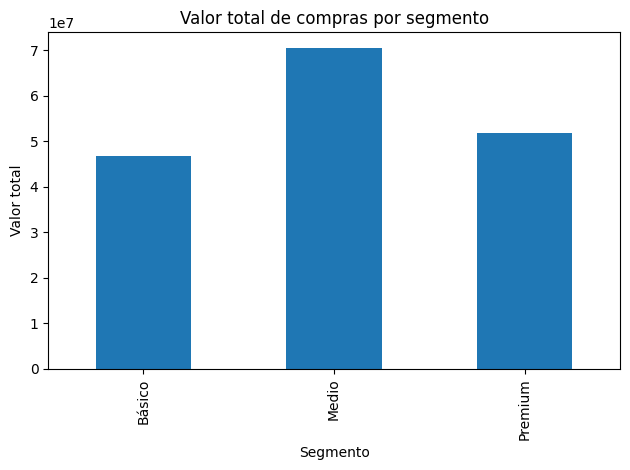

<Figure size 800x500 with 0 Axes>

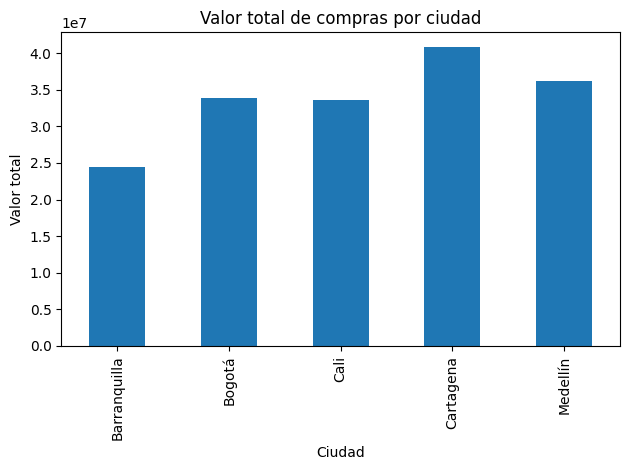

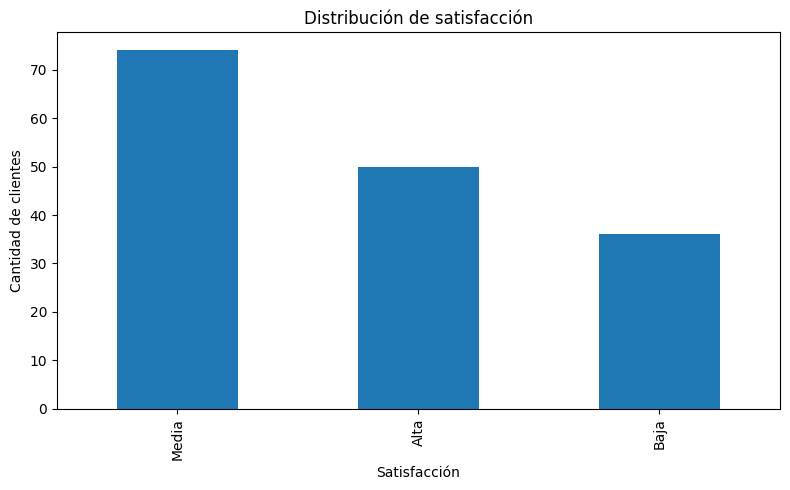

In [21]:
plt.figure(figsize=(8, 5))
indicadores_segmento.plot(kind="bar", x="Segmento", y="ValorTotal", legend=False)
plt.title("Valor total de compras por segmento")
plt.xlabel("Segmento")
plt.ylabel("Valor total")
plt.tight_layout()
plt.savefig(OUT_DIR / "valor_total_por_segmento.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
indicadores_ciudad.plot(kind="bar", x="Ciudad", y="ValorTotal", legend=False)
plt.title("Valor total de compras por ciudad")
plt.xlabel("Ciudad")
plt.ylabel("Valor total")
plt.tight_layout()
plt.savefig(OUT_DIR / "valor_total_por_ciudad.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
dataset["Satisfaccion"].value_counts().plot(kind="bar")
plt.title("Distribución de satisfacción")
plt.xlabel("Satisfacción")
plt.ylabel("Cantidad de clientes")
plt.tight_layout()
plt.savefig(OUT_DIR / "distribucion_satisfaccion.png", dpi=150)
plt.show()

## 11. Exportación de resultados

In [22]:
dataset.to_csv(OUT_DIR / "dataset_integrado_clientes.csv", index=False, encoding="utf-8-sig")
indicadores_segmento.to_csv(OUT_DIR / "indicadores_segmento.csv", index=False, encoding="utf-8-sig")
indicadores_ciudad.to_csv(OUT_DIR / "indicadores_ciudad.csv", index=False, encoding="utf-8-sig")

reporte = []
reporte.append("REPORTE DE VALIDACIÓN G6V1")
reporte.append("=" * 40)
reporte.append(f"Clientes fuente: {len(clientes)}")
reporte.append(f"Compras fuente: {len(compras)}")
reporte.append(f"Compras sin cliente: {len(compras_sin_cliente)}")
reporte.append(f"Filas dataset integrado: {len(dataset)}")
reporte.append(f"Columnas dataset integrado: {dataset.shape[1]}")
reporte.append(f"Duplicados por ID_Cliente en dataset final: {dataset['ID_Cliente'].duplicated().sum()}")

with open(OUT_DIR / "reporte_validacion_integracion.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(reporte))

print("Archivos exportados en:", OUT_DIR)

Archivos exportados en: ..\08_revision\evidencias


## 12. Preguntas de análisis

1. ¿Por qué se agregaron las compras antes de integrarlas?
2. ¿Qué significa que existan compras con ID_Cliente inexistente?
3. ¿Qué variables del dataset integrado podrían servir para análisis comercial?
4. ¿Qué limitaciones tendría este dataset si se usara para IA?
5. ¿Qué controles de calidad agregaría en una empresa real?

### Respuestas del aprendiz

**1. ¿Por qué se agregaron las compras antes de integrarlas?**

Porque la tabla compras tiene varias filas por cada cliente (una fila por cada compra). 
Si se uniera directamente con el maestro de clientes, se duplicarían los clientes en el dataset final. 
Al agregar primero (contar compras, sumar valores, calcular promedio), se obtiene una sola fila 
por cliente con sus indicadores resumen.

**2. ¿Qué significa que existan compras con ID_Cliente inexistente?**

Significa que hay transacciones que no se pueden asociar a ningún cliente registrado (C9999 y C8888). 
Esto puede ocurrir por errores al digitar, datos de prueba sin depurar, o clientes dados de baja. 
Se encontraron 2 casos y se excluyeron del análisis por no tener trazabilidad.

**3. ¿Qué variables del dataset integrado podrían servir para análisis comercial?**

- **Segmento y Ciudad**: para segmentar el mercado y diseñar estrategias por zona o tipo de cliente.
- **TotalCompras y ValorTotalCompras**: para identificar clientes frecuentes y de alto valor.
- **TicketPromedio**: para conocer el gasto promedio por visita.
- **VisitasWebUltimoMes y FuenteWeb**: para medir el alcance digital y saber cómo llegan los clientes.
- **Satisfaccion y QuejasUltimos6M**: para evaluar la experiencia del cliente y detectar problemas.

**4. ¿Qué limitaciones tendría este dataset si se usara para IA?**

Solo 160 registros (muestra muy pequeña para modelos predictivos), no hay datos históricos 
para analizar tendencias, las variables categóricas necesitan convertirse a números, 
y no hay series de tiempo para detectar patrones estacionales.

**5. ¿Qué controles de calidad agregaría en una empresa real?**

Validación automática al ingresar datos para evitar IDs inexistentes, reglas que impidan 
crear compras sin un cliente válido, alertas periódicas de duplicados, registro de auditoría 
de cambios, y un proceso de estandarización automática de formatos antes de cargar los datos.

In [1]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../03_data/empresa_integracion.db")

df = pd.read_sql_query("SELECT * FROM satisfaccion_clientes", conn)

df.to_csv("../03_data/satisfaccion_clientes.csv", index=False)

conn.close()

print("Archivo exportado correctamente.")

Archivo exportado correctamente.
